# Notebook 02 — Geometric Asian Option: Exact Closed-Form Pricing

**Option Pricing Horizon** | Task 2 of 5

---

## Learning Objectives
1. Understand why Asian options are cheaper than vanilla Europeans
2. Derive the log-normal distribution of the discrete geometric average under GBM
3. Derive the Kemna-Vorst adjusted Black-Scholes formula for geometric Asian options
4. Visualise how monitoring frequency N affects the adjusted parameters and price
5. Verify the formula against direct Monte Carlo simulation

---

## 1. Product Specification

### 1.1 Payoff Definition

A **discrete geometric Asian call** with N monitoring dates $t_1 < t_2 < \cdots < t_N = T$
pays at maturity:

$$\text{Payoff} = \max\!\left(A_{\text{geo}} - K,\; 0\right)$$

where the **geometric average** is:

$$A_{\text{geo}} = \left(\prod_{i=1}^{N} S_{t_i}\right)^{1/N}
= \exp\!\left(\frac{1}{N}\sum_{i=1}^{N} \ln S_{t_i}\right)$$

### 1.2 Why Geometric < Arithmetic?

By the **AM-GM inequality**: $A_{\text{geo}} \le A_{\text{arith}}$ always.

Therefore: $\text{GeomAsian price} \le \text{ArithAsian price} \le \text{European price}$.

### 1.3 Assumptions
- Underlying follows risk-neutral GBM: $dS_t = r S_t dt + \sigma S_t dW_t^Q$
- No dividends ($q = 0$)
- European-style exercise (payoff only at $T$)
- Equally spaced monitoring dates: $t_i = i \cdot \Delta t$, $\Delta t = T/N$

---

## 2. Derivation: Log-Normality of the Geometric Average

Under GBM, $S_{t_i} = S_0 \exp\!\left[(r - \sigma^2/2)t_i + \sigma W_{t_i}\right]$, so:

$$\ln A_{\text{geo}} = \ln S_0 + \frac{1}{N}\sum_{i=1}^{N}\left[(r - \tfrac{\sigma^2}{2})t_i + \sigma W_{t_i}\right]$$

This is a **linear combination of jointly normal random variables** — so $\ln A_{\text{geo}}$ is
normal, and $A_{\text{geo}}$ is **log-normal**.

### Step 1 — Mean of $\ln A_{\text{geo}}/S_0$

$$\mu_G = (r - \tfrac{\sigma^2}{2}) \cdot \frac{\Delta t (N+1)}{2}$$

*(arithmetic series: $\frac{1}{N}\sum_{i=1}^{N} i\Delta t = \Delta t \frac{N+1}{2}$)*

### Step 2 — Variance of $\ln A_{\text{geo}}/S_0$

Using $\text{Cov}[W_{t_i}, W_{t_j}] = \min(t_i, t_j)$:

$$\sigma_G^2 = \sigma^2 \cdot \frac{\Delta t^2 (N+1)(2N+1)}{6}$$

### Step 3 — Adjusted Forward

$$F_G = S_0 \cdot e^{\mu_G + \sigma_G^2/2}$$

### Step 4 — Closed-Form Price

$$\boxed{C_{\text{geo}} = e^{-rT}\left[F_G \Phi(d_1^G) - K \Phi(d_2^G)\right]}$$

$$d_1^G = \frac{\ln(F_G/K) + \sigma_G^2/2}{\sigma_G}, \qquad d_2^G = d_1^G - \sigma_G$$

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
import warnings
warnings.filterwarnings('ignore')

from option_pricing_horizon.common.market_params import MarketParams
from option_pricing_horizon.asian.geometric import (
    geometric_asian_call, geometric_asian_put,
    geometric_asian_price, geo_asian_adjusted_params
)
from option_pricing_horizon.european.black_scholes import bs_call_price, bs_put_price
from option_pricing_horizon.common.simulation import simulate_gbm_paths
from option_pricing_horizon.asian.payoffs import geometric_average_payoff

plt.rcParams.update({
    'figure.facecolor': 'white', 'axes.facecolor': '#f8f9fa',
    'axes.grid': True, 'grid.alpha': 0.4,
    'font.size': 11, 'axes.titlesize': 13, 'axes.labelsize': 11,
})

mp = MarketParams.baseline()
print(mp)

MarketParams(S0=100.0, K=100.0, r=0.03, sigma=0.2, T=1.0, N=252, q=0.0)


## 3. Adjusted Parameters: How N Changes σ_G and F_G

In [2]:
N_values = [1, 2, 4, 12, 52, 126, 252, 504, 1260]
rows = []
for N in N_values:
    p = geo_asian_adjusted_params(mp.S0, mp.K, mp.r, mp.sigma, mp.T, N)
    rows.append({
        'N':            N,
        'mu_G':         round(p['mu_G'],     6),
        'sigma_G':      round(p['sigma_G'],  6),
        'sigma_G_ann':  round(p['sigma_G_ann'], 6),
        'F_G':          round(p['F_G'],      4),
    })

param_df = pd.DataFrame(rows).set_index('N')
param_df.index.name = 'N (monitoring dates)'

# Theoretical limit as N→∞ (continuous geometric average)
sigma_cont = mp.sigma / np.sqrt(3)
mu_cont    = (mp.r - mp.sigma**2 / 2) * mp.T / 2
F_cont     = mp.S0 * np.exp(mu_cont + 0.5 * sigma_cont**2)

print("Adjusted Parameters vs Monitoring Frequency N")
print(param_df.to_string())
print(f"\nContinuous limit (N→∞): σ_G/√T = σ/√3 = {sigma_cont:.6f}, F_G = {F_cont:.4f}")

Adjusted Parameters vs Monitoring Frequency N
                          mu_G   sigma_G  sigma_G_ann       F_G
N (monitoring dates)                                           
1                     0.010000  0.200000     0.200000  103.0455
2                     0.007500  0.158114     0.158114  102.0201
4                     0.006250  0.136931     0.136931  101.5748
12                    0.005417  0.122663     0.122663  101.3024
52                    0.005096  0.117134     0.117134  101.2028
126                   0.005040  0.116157     0.116157  101.1856
252                   0.005020  0.115814     0.115814  101.1795
504                   0.005010  0.115642     0.115642  101.1765
1260                  0.005004  0.115539     0.115539  101.1747

Continuous limit (N→∞): σ_G/√T = σ/√3 = 0.115470, F_G = 101.1735


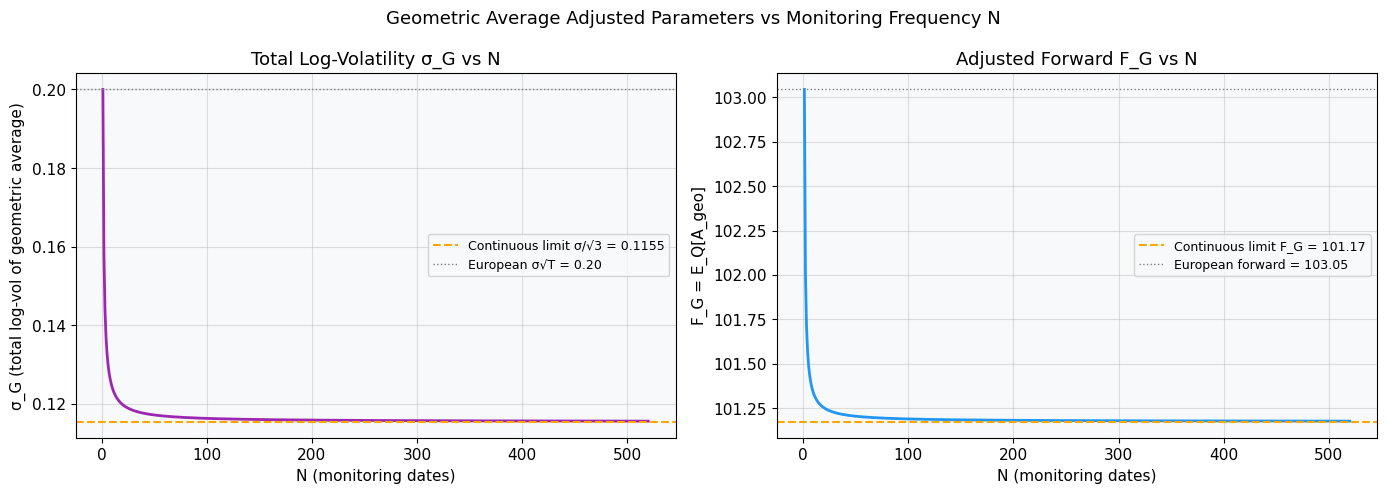


Key insight: as N increases, σ_G → σ/√3 and F_G → S0·exp((r - σ²/6)·T/2)
Averaging shrinks volatility from σ to σ/√3 (a factor of ~0.577)


In [3]:
N_dense = np.arange(1, 521)
sigma_G_vals = [geo_asian_adjusted_params(mp.S0, mp.K, mp.r, mp.sigma, mp.T, int(N))['sigma_G']
                for N in N_dense]
F_G_vals     = [geo_asian_adjusted_params(mp.S0, mp.K, mp.r, mp.sigma, mp.T, int(N))['F_G']
                for N in N_dense]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Geometric Average Adjusted Parameters vs Monitoring Frequency N', fontsize=13)

axes[0].plot(N_dense, sigma_G_vals, color='#9C27B0', lw=2)
axes[0].axhline(sigma_cont, color='orange', lw=1.5, ls='--',
                label=f'Continuous limit σ/√3 = {sigma_cont:.4f}')
axes[0].axhline(mp.sigma * np.sqrt(mp.T), color='grey', lw=1, ls=':',
                label=f'European σ√T = {mp.sigma:.2f}')
axes[0].set_xlabel('N (monitoring dates)')
axes[0].set_ylabel('σ_G (total log-vol of geometric average)')
axes[0].set_title('Total Log-Volatility σ_G vs N')
axes[0].legend(fontsize=9)

axes[1].plot(N_dense, F_G_vals, color='#2196F3', lw=2)
axes[1].axhline(F_cont, color='orange', lw=1.5, ls='--',
                label=f'Continuous limit F_G = {F_cont:.2f}')
forward = mp.S0 * np.exp(mp.r * mp.T)
axes[1].axhline(forward, color='grey', lw=1, ls=':',
                label=f'European forward = {forward:.2f}')
axes[1].set_xlabel('N (monitoring dates)')
axes[1].set_ylabel('F_G = E_Q[A_geo]')
axes[1].set_title('Adjusted Forward F_G vs N')
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.show()

print("\nKey insight: as N increases, σ_G → σ/√3 and F_G → S0·exp((r - σ²/6)·T/2)")
print("Averaging shrinks volatility from σ to σ/√3 (a factor of ~0.577)")

## 4. Geometric Asian Price vs Monitoring Frequency

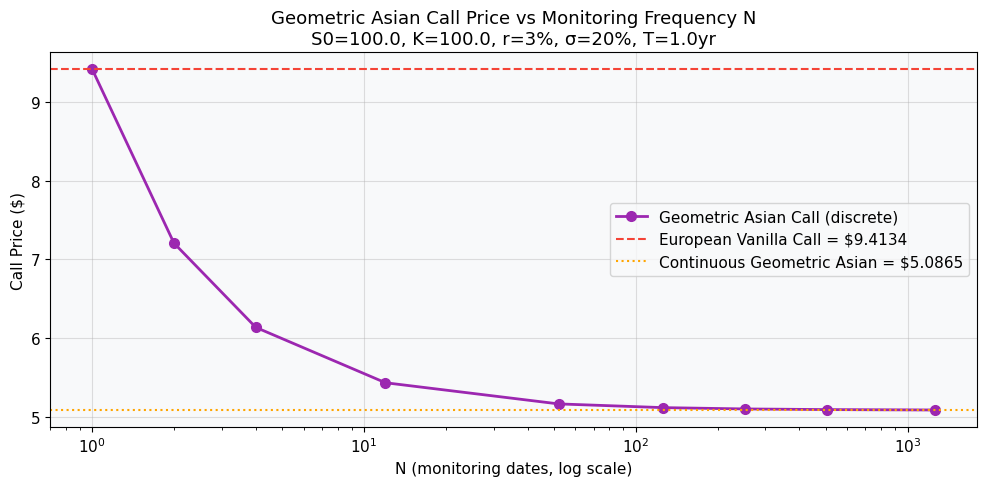


       N   Geo Asian Price    vs European
  ------  ----------------  -------------
       1  $       9.413403         +0.00%
       2  $       7.206261        -23.45%
       4  $       6.137644        -34.80%
      12  $       5.435333        -42.26%
      52  $       5.166873        -45.11%
     126  $       5.119650        -45.61%
     252  $       5.103063        -45.79%
     504  $       5.094771        -45.88%
    1260  $       5.089796        -45.93%
       ∞  $       5.086479        -45.97%  ← continuous limit
  vanilla  $       9.413403          0.00%


In [4]:
N_list = [1, 2, 4, 12, 52, 126, 252, 504, 1260]
geo_prices = [geometric_asian_call(mp.S0, mp.K, mp.r, mp.sigma, mp.T, N) for N in N_list]
vanilla    = bs_call_price(mp.S0, mp.K, mp.r, mp.sigma, mp.T)

# Continuous-limit geometric Asian price
sigma_cont = mp.sigma / np.sqrt(3)
mu_cont    = (mp.r - mp.sigma**2 / 2) * mp.T / 2
F_cont_v   = mp.S0 * np.exp(mu_cont + 0.5 * sigma_cont**2)
disc       = np.exp(-mp.r * mp.T)
from option_pricing_horizon.common.math_utils import norm_cdf
d1c = (np.log(F_cont_v / mp.K) + 0.5 * sigma_cont**2) / sigma_cont
d2c = d1c - sigma_cont
geo_cont_price = disc * (F_cont_v * norm_cdf(d1c) - mp.K * norm_cdf(d2c))

fig, ax = plt.subplots(figsize=(10, 5))
ax.semilogx(N_list, geo_prices, 'o-', color='#9C27B0', lw=2, ms=7, label='Geometric Asian Call (discrete)')
ax.axhline(vanilla,        color='#F44336',  lw=1.5, ls='--', label=f'European Vanilla Call = ${vanilla:.4f}')
ax.axhline(geo_cont_price, color='orange',   lw=1.5, ls=':',  label=f'Continuous Geometric Asian = ${geo_cont_price:.4f}')
ax.set_xlabel('N (monitoring dates, log scale)')
ax.set_ylabel('Call Price ($)')
ax.set_title('Geometric Asian Call Price vs Monitoring Frequency N\n'
             f'S0={mp.S0}, K={mp.K}, r={mp.r:.0%}, σ={mp.sigma:.0%}, T={mp.T}yr')
ax.legend()
plt.tight_layout()
plt.show()

print(f"\n  {'N':>6}  {'Geo Asian Price':>16}  {'vs European':>13}")
print(f"  {'------':>6}  {'----------------':>16}  {'-------------':>13}")
for N, p in zip(N_list, geo_prices):
    print(f"  {N:>6}  ${p:>15.6f}  {(p/vanilla - 1)*100:>+12.2f}%")
print(f"  {'∞':>6}  ${geo_cont_price:>15.6f}  {(geo_cont_price/vanilla - 1)*100:>+12.2f}%  ← continuous limit")
print(f"  {'vanilla':>6}  ${vanilla:>15.6f}  {'0.00%':>13}")

## 5. Price vs Spot and Strike

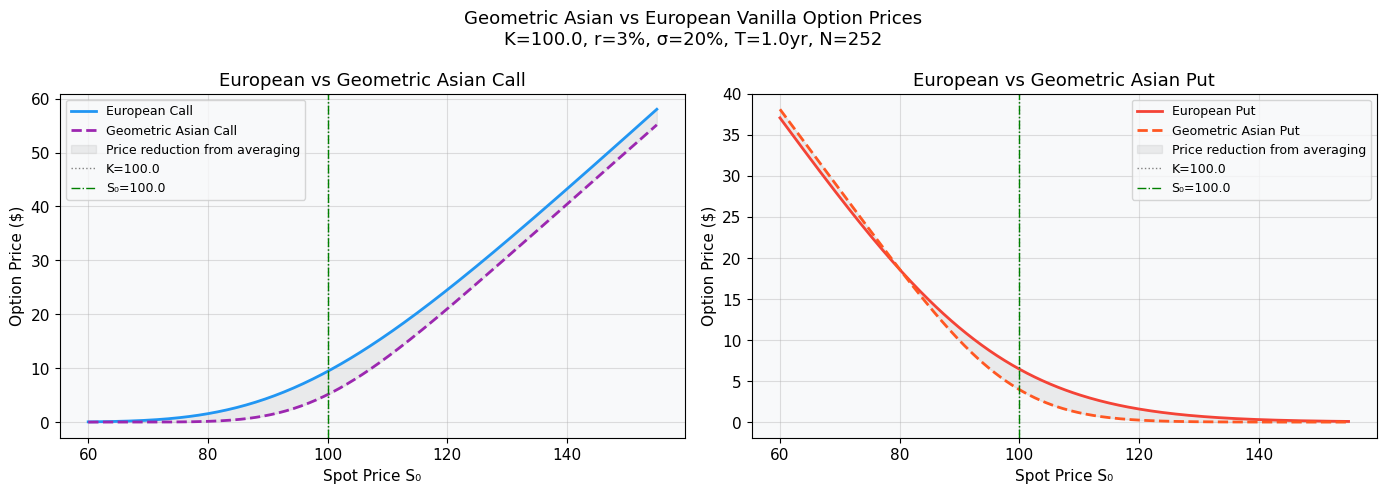

In [5]:
S_range = np.linspace(60, 155, 300)
N_demo  = 252

geo_calls   = np.array([geometric_asian_call(S, mp.K, mp.r, mp.sigma, mp.T, N_demo) for S in S_range])
geo_puts    = np.array([geometric_asian_put(S, mp.K, mp.r, mp.sigma, mp.T, N_demo)  for S in S_range])
van_calls   = np.array([bs_call_price(S, mp.K, mp.r, mp.sigma, mp.T) for S in S_range])
van_puts    = np.array([bs_put_price(S, mp.K, mp.r, mp.sigma, mp.T)  for S in S_range])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Geometric Asian vs European Vanilla Option Prices\n'
             f'K={mp.K}, r={mp.r:.0%}, σ={mp.sigma:.0%}, T={mp.T}yr, N={N_demo}', fontsize=13)

for ax, geo, van, label, color_geo, color_van in [
    (axes[0], geo_calls, van_calls, 'Call', '#9C27B0', '#2196F3'),
    (axes[1], geo_puts,  van_puts,  'Put',  '#FF5722', '#F44336'),
]:
    ax.plot(S_range, van, color=color_van, lw=2,   label=f'European {label}')
    ax.plot(S_range, geo, color=color_geo, lw=2, ls='--', label=f'Geometric Asian {label}')
    ax.fill_between(S_range, geo, van, alpha=0.12, color='grey', label='Price reduction from averaging')
    ax.axvline(mp.K,  color='grey',  lw=1, ls=':',  label=f'K={mp.K}')
    ax.axvline(mp.S0, color='green', lw=1, ls='-.', label=f'S₀={mp.S0}')
    ax.set_xlabel('Spot Price S₀')
    ax.set_ylabel('Option Price ($)')
    ax.set_title(f'European vs Geometric Asian {label}')
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

## 6. Monte Carlo Verification

We verify the closed-form price by directly simulating geometric average payoffs.
The two must agree to within Monte Carlo statistical error.

In [6]:
np.random.seed(42)
n_paths = 500_000
paths   = simulate_gbm_paths(mp.S0, mp.r, mp.sigma, mp.T, mp.N, n_paths, seed=42, antithetic=True)
disc    = np.exp(-mp.r * mp.T)

geo_payoffs = disc * geometric_average_payoff(paths, mp.K, 'call')
mc_price    = geo_payoffs.mean()
mc_se       = geo_payoffs.std(ddof=1) / np.sqrt(n_paths)
exact_price = geometric_asian_call(mp.S0, mp.K, mp.r, mp.sigma, mp.T, mp.N)

print("Geometric Asian Call — Closed-Form vs Monte Carlo Verification")
print(f"  Closed-form (exact) :  ${exact_price:.8f}")
print(f"  Monte Carlo (500k)  :  ${mc_price:.8f}  ±  {mc_se:.8f}")
print(f"  Difference          :  ${abs(exact_price - mc_price):.8f}")
print(f"  Within 3 SE?        :  {abs(exact_price - mc_price) < 3*mc_se}")
print(f"  95% CI              :  [${mc_price - 1.96*mc_se:.8f},  ${mc_price + 1.96*mc_se:.8f}]")
print(f"  Exact inside CI?    :  {mc_price - 1.96*mc_se <= exact_price <= mc_price + 1.96*mc_se}")

Geometric Asian Call — Closed-Form vs Monte Carlo Verification
  Closed-form (exact) :  $5.10306328
  Monte Carlo (500k)  :  $5.11929029  ±  0.01060648
  Difference          :  $0.01622702
  Within 3 SE?        :  True
  95% CI              :  [$5.09850159,  $5.14007899]
  Exact inside CI?    :  True


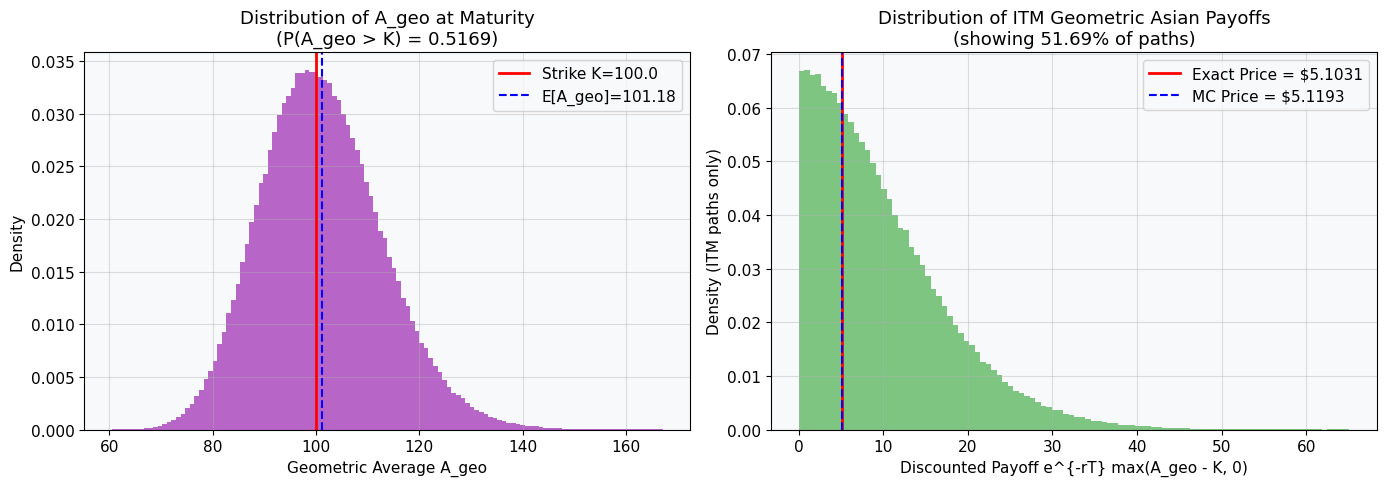

In [7]:
# Visualise the distribution of geometric average payoffs
nonzero = geo_payoffs[geo_payoffs > 0]
p_itm   = len(nonzero) / len(geo_payoffs)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Distribution of geometric averages
A_geo = np.exp(np.log(paths).mean(axis=1))
axes[0].hist(A_geo, bins=120, color='#9C27B0', alpha=0.7, density=True, edgecolor='none')
axes[0].axvline(mp.K,     color='red',   lw=2,   label=f'Strike K={mp.K}')
axes[0].axvline(A_geo.mean(), color='blue', lw=1.5, ls='--', label=f'E[A_geo]={A_geo.mean():.2f}')
axes[0].set_xlabel('Geometric Average A_geo')
axes[0].set_ylabel('Density')
axes[0].set_title(f'Distribution of A_geo at Maturity\n(P(A_geo > K) = {p_itm:.4f})')
axes[0].legend()

# Distribution of discounted payoffs
axes[1].hist(geo_payoffs[geo_payoffs > 0], bins=100, color='#4CAF50', alpha=0.7,
             density=True, edgecolor='none')
axes[1].axvline(exact_price, color='red', lw=2, label=f'Exact Price = ${exact_price:.4f}')
axes[1].axvline(mc_price,    color='blue', lw=1.5, ls='--', label=f'MC Price = ${mc_price:.4f}')
axes[1].set_xlabel('Discounted Payoff e^{-rT} max(A_geo - K, 0)')
axes[1].set_ylabel('Density (ITM paths only)')
axes[1].set_title(f'Distribution of ITM Geometric Asian Payoffs\n(showing {p_itm:.2%} of paths)')
axes[1].legend()

plt.tight_layout()
plt.show()

## 7. Put-Call Parity for Geometric Asian Options

$$C_{\text{geo}} - P_{\text{geo}} = e^{-rT}(F_G - K)$$

This holds analytically and we verify it numerically.

In [8]:
test_cases = [
    (80,  100), (90,  100), (100, 100), (110, 100), (130, 100),
    (100,  90), (100, 110),
]

rows = []
for S, K_ in test_cases:
    call  = geometric_asian_call(S, K_, mp.r, mp.sigma, mp.T, mp.N)
    put   = geometric_asian_put(S, K_, mp.r, mp.sigma, mp.T, mp.N)
    p     = geo_asian_adjusted_params(S, K_, mp.r, mp.sigma, mp.T, mp.N)
    disc  = np.exp(-mp.r * mp.T)
    parity_rhs = disc * (p['F_G'] - K_)
    error = abs(call - put - parity_rhs)
    rows.append({
        'S₀': S, 'K': K_,
        'Call': round(call, 6), 'Put': round(put, 6),
        'C - P': round(call - put, 6),
        'e^{-rT}(F_G - K)': round(parity_rhs, 6),
        'Error': f'{error:.2e}'
    })

pc_df = pd.DataFrame(rows)
print("Geometric Asian Put-Call Parity Verification")
print(pc_df.to_string(index=False))
print("\nAll errors at machine precision (~1e-15) — parity holds exactly.")

Geometric Asian Put-Call Parity Verification
 S₀   K      Call       Put      C - P  e^{-rT}(F_G - K)    Error
 80 100  0.135169 18.628346 -18.493178        -18.493178 0.00e+00
 90 100  1.268786  9.943041  -8.674256         -8.674256 3.55e-15
100 100  5.103063  3.958397   1.144666          1.144666 6.44e-15
110 100 12.101293  1.137705  10.963588         10.963588 1.60e-14
130 100 30.640134  0.038702  30.601432         30.601432 7.11e-15
100  90 11.723200  0.874078  10.849122         10.849122 3.55e-15
100 110  1.631136 10.190925  -8.559789         -8.559789 5.33e-15

All errors at machine precision (~1e-15) — parity holds exactly.
